# Does the small-N dislocation carry signal? (event-rate test) — and can N be too small?

Notebook 03 showed the merged-clock per-exchange EMA *dislocates* from the
own-clock EMA at small N, and argued that dislocation is where the cross-exchange
signal lives. This tests it directly on a tractable target: **event rate** (trade
intensity is far more predictable than price), asking two things:

1. Does a small-N merged-clock rate feature **predict byb's forward event rate**?
2. **Is there an N too small** — a floor below which the feature is just sampling noise?

**Rate feature (merged clock, scale N), per the design.** `rate_e = N_e / S`, where
`N_e` is the merged-clock flow-EMA of the indicator "this merged tick is from e"
(e's share of flow) and `S` is the merged-clock EMA of the inter-tick time
(seconds per merged tick). So `rate_e` is e's events/second, fully causal, both
EMAs at the same scale N. **Target:** byb's realised forward rate over horizon H.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import load_block, list_blocks

COIN = "eth_usdt_p"; EX = ["bin", "byb", "okx"]; BYB = 1
BLOCK = list_blocks(f"bin_{COIN}", "trade")[0]
NS = [20000, 10000, 5000, 2000, 1000, 500, 200, 100, 50, 25, 10, 5, 3, 2]
HS = [0.05, 0.1, 0.2, 0.5, 1.0, 5.0]
WARMUP_S = 600.0
print("block:", BLOCK)

block: holocron.20260520T135822.0


## Merged trade stream + rate feature

In [2]:
rxs, eids = [], []
for k, ex in enumerate(EX):
    td = (load_block(BLOCK, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)).sort("rx_time"))   # drop bin zero-prints
    rxs.append(td["rx_time"].cast(pl.Int64).to_numpy()); eids.append(np.full(len(td), k))
mrx = np.concatenate(rxs); meid = np.concatenate(eids)
o = np.argsort(mrx, kind="stable"); mrx, meid = mrx[o], meid[o]
M = len(mrx)
dt = np.empty(M); dt[1:] = np.diff(mrx) / 1e9; dt[0] = dt[1]      # seconds per merged tick
byb_rx = mrx[meid == BYB]

# causal evaluation grid (0.2 s) + forward-rate target
t0 = mrx[0] + int(WARMUP_S * 1e9); t1 = mrx[-1] - int(max(HS) * 1e9)
grid = np.arange(t0, t1, int(0.2 * 1e9))
gi = np.searchsorted(mrx, grid, "right") - 1                      # last merged tick <= t_g

def target(H):                                                   # byb realised fwd rate, events/s
    return (np.searchsorted(byb_rx, grid + int(H * 1e9), "right")
            - np.searchsorted(byb_rx, grid, "right")) / H

def rate_feature(k, N):
    a = 2.0 / (N + 1.0)
    Ne = lfilter([a], [1.0, -(1.0 - a)], (meid == k).astype(np.float64))[gi]
    S = lfilter([a], [1.0, -(1.0 - a)], dt)[gi]
    return Ne / S

feats = {(N, k): rate_feature(k, N) for N in NS for k in range(len(EX))}
print(f"M={M:,}  byb={len(byb_rx):,}  grid={len(grid):,} samples")

M=6,198,188  byb=1,618,754  grid=428,953 samples


## Oracle check — `lfilter` rate vs a dead-simple arrival-order loop

Same discipline as nb03: stream every merged trade in arrival order, keep the flow
EMAs `N_e` and `S` by hand (decay all one tick, inject), and confirm `N_e/S` matches
the filtered feature.

In [3]:
def rate_loop(N, k):
    a = 2.0 / (N + 1.0); lam = 1.0 - a
    ne = 0.0; s = 0.0; out = np.empty(M)
    md_, dd = meid.tolist(), dt.tolist()
    for m in range(M):
        ne = lam * ne + (a if md_[m] == k else 0.0)
        s = lam * s + a * dd[m]
        out[m] = ne / s if s > 0 else 0.0
    return out[gi]

assert np.allclose(rate_loop(100, BYB), feats[(100, BYB)], rtol=1e-6, atol=1e-9)
print("N=100 byb: lfilter rate == arrival-order loop  OK")

N=100 byb: lfilter rate == arrival-order loop  OK


## Predictive IC vs N — H = 1 s

Spearman IC of each venue's rate feature against byb's forward rate. Watch the
**interior peak**, the **collapse at small N** (the floor), and the **cross-venue
crossover** — bin/okx overtaking byb's own as N shrinks.

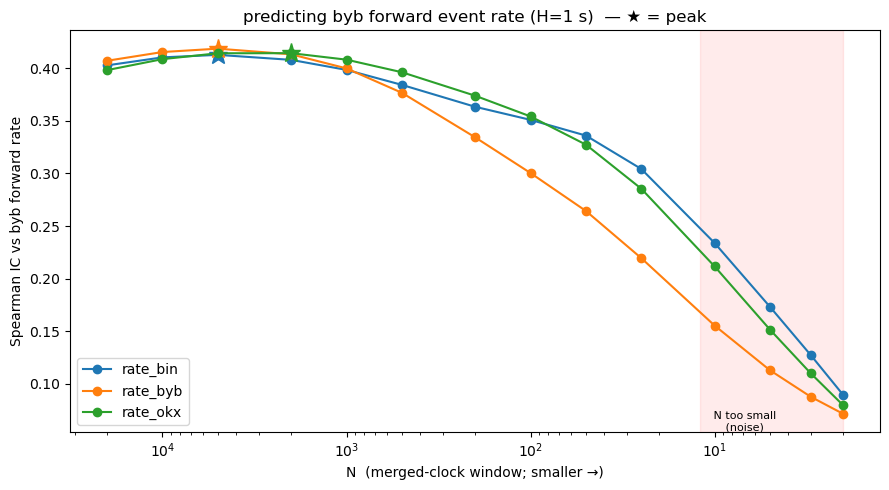

In [4]:
fwd1 = target(1.0)
ic1 = {k: np.array([spearmanr(feats[(N, k)], fwd1).statistic for N in NS]) for k in range(len(EX))}

fig, ax = plt.subplots(figsize=(9, 5))
for k, ex, c in zip(range(len(EX)), EX, ["C0", "C1", "C2"]):
    ax.plot(NS, ic1[k], "o-", color=c, label=f"rate_{ex}")
    pk = int(np.argmax(ic1[k])); ax.plot(NS[pk], ic1[k][pk], "*", ms=14, color=c)
ax.set_xscale("log"); ax.invert_xaxis()
ax.set_xlabel("N  (merged-clock window; smaller →)"); ax.set_ylabel("Spearman IC vs byb forward rate")
ax.set_title("predicting byb forward event rate (H=1 s)  — ★ = peak")
ax.axvspan(2, 12, alpha=0.08, color="red"); ax.text(7, ax.get_ylim()[0], " N too small\n (noise)", fontsize=8, va="bottom", ha="center")
ax.legend(); fig.tight_layout()

## Horizon dependence — the floor and the crossover both move with horizon

Left: byb's own rate feature across horizons — the optimum and the small-N collapse.
Right: at the **shortest** horizon (50 ms, right in the bin→byb lead/lag band), the
small-N **cross-venue** feature (bin) beats byb's own at *every* N.

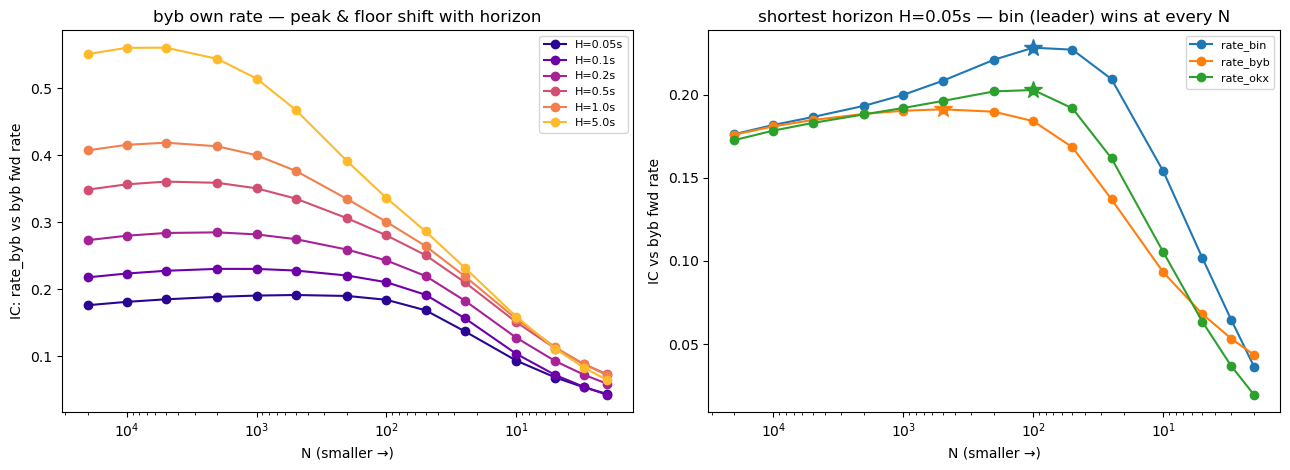

In [5]:
ic = {(H, k): np.array([spearmanr(feats[(N, k)], target(H)).statistic for N in NS])
      for H in HS for k in range(len(EX))}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
hcolors = plt.cm.plasma(np.linspace(0.05, 0.85, len(HS)))
for H, c in zip(HS, hcolors):
    axL.plot(NS, ic[(H, BYB)], "o-", color=c, label=f"H={H}s")
axL.set_xscale("log"); axL.invert_xaxis(); axL.set_xlabel("N (smaller →)")
axL.set_ylabel("IC: rate_byb vs byb fwd rate"); axL.set_title("byb own rate — peak & floor shift with horizon"); axL.legend(fontsize=8)
Hs = HS[0]
for k, ex, c in zip(range(len(EX)), EX, ["C0", "C1", "C2"]):
    axR.plot(NS, ic[(Hs, k)], "o-", color=c, label=f"rate_{ex}")
    pk = int(np.argmax(ic[(Hs, k)])); axR.plot(NS[pk], ic[(Hs, k)][pk], "*", ms=13, color=c)
axR.set_xscale("log"); axR.invert_xaxis(); axR.set_xlabel("N (smaller →)")
axR.set_ylabel("IC vs byb fwd rate"); axR.set_title(f"shortest horizon H={Hs}s — bin (leader) wins at every N"); axR.legend(fontsize=8)
fig.tight_layout()

## Read-out

**Yes, the small-N dislocation carries real predictive signal — and yes, N can be too small.**

- **There's a floor.** IC vs N has an interior optimum and collapses toward 0 at tiny
  N (≈0.42 → 0.07 by N=2 at H=1 s). Below a few tens of events the merged-clock rate
  feature is dominated by sampling noise — so the dislocation is *not* infinitely
  exploitable; there is a smallest-useful N.
- **The optimum tracks the horizon.** Long horizons want heavy smoothing (H≥0.5 s →
  N≈5000); short horizons want small N (H=0.05–0.2 s → bin peaks at N≈100). Going
  *below* the optimum always hurts — that's the floor.
- **Cross-venue small-N features beat byb's own — the key validation, and it turns
  decisive at short horizons.** bin carries ~60% of flow, so its small-N rate is a
  cleaner, fresher read on the common activity than byb's own under-sampled estimate.
  bin>byb below N≈2000 at H=0.2 s — and at the **50–100 ms** horizons (right in the
  bin→byb lead/lag band) **bin @ N≈100 beats byb's best at *every* N**: byb's next
  ~50 ms is better foretold by bin's recent flow than by byb's own history. That is
  the small-N merged-clock dislocation paying off as genuine cross-exchange alpha.

So the dislocation at small N is signal, not noise — strongest exactly where the
lead/lag lives (nb03) — down to a horizon-dependent floor of a few tens of events.
Below that (single-digit N) it does become noise. **Practically:** keep the single
merged clock, expose all scales, and lean on small-N *cross-venue* rate/intensity
features for short-horizon prediction — but don't go below ~N=25–100 for sub-second
targets.

## Analysis & recommendations

Synthesis of nb03 (EMA validation + lead/lag) and this notebook, for the feature
design in `docs/nn_features.md`. **One block of `eth_usdt_p`** — the specific N
values are illustrative (they shift with venue mix / coin / regime); the *shape*
(interior optimum, cross-venue crossover, noise floor) is the robust finding.

### Suggested N (for a 50–100 ms prediction target)

- **Best single feature: the leader at N≈100** — `bin @ N≈100` (IC 0.23 @ 50 ms,
  0.26 @ 100 ms), beating byb's own at *every* N.
- **Optimum is venue-specific:** bin / okx peak at **N≈100** (flat 50–200); byb's
  *own* rate wants **N≈500–2000** (under-sampled → needs heavier smoothing).
- **Feature set to expose to the model:** `N ∈ {50, 100, 200, 500, 1000}` per venue,
  + a **~5000** anchor for the slow level — spans the leader's small-N sweet spot and
  byb's larger-N own optimum.
- **Floor — N can be too small:** below ~N=25–50 the IC collapses (N=10 loses ⅓–½;
  N=5 ~⅔). **Smallest useful scale ≈ 50; don't go below ~25.**
- The best window for a *50 ms* target is N≈100 ≈ a **1.4 s** window — bias–variance
  (you need ~100 events for a stable rate estimate), not horizon-matching.

### When to stop the per-exchange decomposition

- **Crossover at N ≈ 500–1000.** The venue IC spread (`bin − byb`) is ~0 above
  N≈1000 (0.002 @ N=5000) and fans out below (0.044 @ N=100) — visible in the
  IC-vs-N plots. Above the crossover the three per-exchange rate *levels* are
  redundant; below it the leader pulls ahead.
- **Horizon face of the same line:** cross-venue beats own only for **H ≤ ~200 ms**;
  by H ≥ 500 ms they are equal.
- **So:** the per-exchange decomposition earns its keep only at **small N (≲ 200–500)
  / short horizons (≲ 200 ms)** — the ≤100 ms lead/lag band. At larger N / longer
  horizons one series carries the same information.

### Clock decision (settled)

- **Keep the merged clock for all N and all venues** — frame consistency: every scale
  is nested in merged-tick units, one code path, one oracle, and the cost is ~0
  (nb03: merged ≈ own to <1% at large N).
- Per-exchange features are informative at small N and **harmlessly redundant** at
  large N (prune slow duplicates later only if feature count bites).
- The slow cross-venue **share/ratio** (`W_bin/W_byb`) stays a separate,
  non-redundant slow object.